# 🎓 Logistic Regression — Placement Prediction

**Dataset:** `placement.csv` — 550 students
**Goal:** predict whether a student gets placed — `placed` = 1 (placed) or 0 (not placed)

## 📘 What is Logistic Regression?

### Definition

**Logistic Regression** is a supervised machine learning algorithm used for **classification** problems. It predicts the **probability** that an input belongs to the positive class (class 1).

It works in three steps:
1. It calculates a weighted sum of the input features plus a bias: **z = w₁x₁ + w₂x₂ + … + wₙxₙ + b**
2. It passes z through the **sigmoid function**, **σ(z) = 1 / (1 + e⁻ᶻ)**, which converts any real number into a probability between 0 and 1.
3. It compares the probability with a **threshold** (usually 0.5): if p ≥ 0.5 the output is class 1, otherwise class 0.

### Formulas

| Step | Formula |
|---|---|
| Weighted sum (raw score) | z = w₁x₁ + w₂x₂ + … + wₙxₙ + b |
| Sigmoid (probability) | p = σ(z) = 1 / (1 + e⁻ᶻ) |
| Decision (threshold 0.5) | class = 1 if p ≥ 0.5, else 0 |

### How sigmoid behaves

| z | −4 | −2 | 0 | 2 | 4 |
|---|---|---|---|---|---|
| σ(z) | 0.02 | 0.12 | **0.50** | 0.88 | 0.98 |

- Large positive z → p close to 1
- Large negative z → p close to 0
- z = 0 → p = 0.5 exactly

### Key points

- It is a **classification** algorithm, even though its name contains "regression".
- The output of sigmoid is always between 0 and 1, so it can be read as a probability.
- The **weights (w)** and the **bias / intercept (b)** are learned from the training data.
- It is mainly used for **binary classification**: placed / not placed, pass / fail, spam / not spam.
- In scikit-learn: `from sklearn.linear_model import LogisticRegression`

## 📥 1. Load the data

> **Flow:** import libraries → read the CSV → first look

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('../Data/placement.csv')
df.head()

,student_id,cgpa,twelfth_percent,branch,internships,projects,backlogs,prep_hours,communication_score,hostel,placed,package_lpa
0,1001,6.94,69.8,ECE,1,3,0,205.0,5.0,No,0,0.00
1,1002,8.82,88.5,CE,0,0,2,156.0,8.0,No,1,8.34
2,1003,7.56,84.2,CSE,0,1,0,191.0,6.0,Yes,0,0.00
3,1004,7.14,64.4,CE,0,0,0,519.0,9.0,No,1,6.34
4,1005,6.38,91.8,IT,1,5,1,410.0,3.0,Yes,0,0.00


In [15]:
df.shape

(550, 12)

In [16]:
df.isnull().sum()

student_id              0
cgpa                   14
twelfth_percent         0
branch                  0
internships             0
projects                0
backlogs                0
prep_hours             22
communication_score    17
hostel                  0
placed                  0
package_lpa             0
dtype: int64

## 🧹 2. Clean the data

> **Flow:** drop columns we will not use → fill missing values with the median

| Column | Why we drop it |
|---|---|
| `student_id` | Just a roll number — it says nothing about placement |
| `package_lpa` | Known only **after** placement (0 for every student who was not placed) — keeping it gives the answer away |
| `branch`, `hostel` | Text columns — dropped to keep today's model numeric only |

In [17]:
df = df.drop(columns=['student_id', 'package_lpa', 'branch', 'hostel'])
df.head()

,cgpa,twelfth_percent,internships,projects,backlogs,prep_hours,communication_score,placed
0,6.94,69.8,1,3,0,205.0,5.0,0
1,8.82,88.5,0,0,2,156.0,8.0,1
2,7.56,84.2,0,1,0,191.0,6.0,0
3,7.14,64.4,0,0,0,519.0,9.0,1
4,6.38,91.8,1,5,1,410.0,3.0,0


In [18]:
df['cgpa'] = df['cgpa'].fillna(df['cgpa'].median())
df['prep_hours'] = df['prep_hours'].fillna(df['prep_hours'].median())
df['communication_score'] = df['communication_score'].fillna(df['communication_score'].median())

df.isnull().sum()

cgpa                   0
twelfth_percent        0
internships            0
projects               0
backlogs               0
prep_hours             0
communication_score    0
placed                 0
dtype: int64

## 🎯 3. Features (X) and target (y)

> **Flow:** X = every column except `placed` → y = `placed`

In [19]:
X = df.drop(columns='placed')
y = df['placed']

X.columns

Index(['cgpa', 'twelfth_percent', 'internships', 'projects', 'backlogs',
       'prep_hours', 'communication_score'],
      dtype='str')

In [20]:
y.value_counts()

placed
1    304
0    246
Name: count, dtype: int64

## ✂️ 4. Train / test split

> **Flow:** 80% of students to train the model → 20% kept aside to test it

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(440, 7) (110, 7)


## 📏 5. Scale the features

> **Flow:** `fit_transform` on train → `transform` on test (the test set never teaches the scaler anything)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
# 🧑‍💻 Live coding starts here

## 🤖 6. Build and train the model

> **Flow:** import `LogisticRegression` → create the model → `fit` on the scaled training data

In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 🔮 7. Predict on the test set

> **Flow:** `predict` on the scaled test data

In [24]:
y_pred = model.predict(X_test_scaled)

## ✅ 8. Accuracy

> **Flow:** compare `y_test` with `y_pred` using `accuracy_score`

In [25]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)

In [26]:
print(score)

0.8636363636363636


In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[45 10]
 [ 5 50]]


Text(50.83333333333333, 0.5, 'Actual')

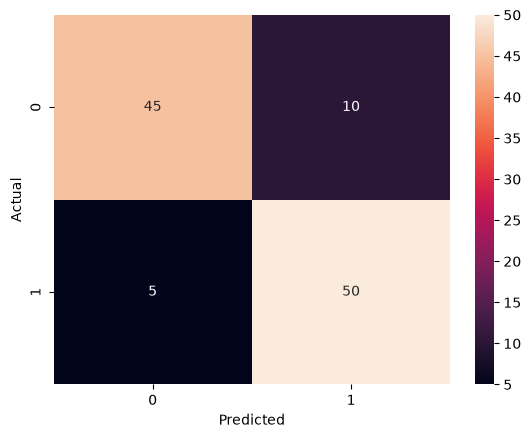

In [30]:
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")